# Flexural Analysis of Singly Reinforced Beams
This is an example of an application of python in reinfoced concrete design and analysis.
This program is used for flexural analysis of singly reinforced beams using an iterative solver for the neutral axis.
The process is outlined as follows:
1. **Initialization**  
    * Define Inputs: Set cross-section dimensions ($b, h$), material strengths ($f'_c, f_y$), and the reinforcement layers ($d_i, A_{si}$).  
    * Calculate $\beta_1$: Determine the Whitney stress block factor based on $f'_c$.  
    * Set Bisection Bounds: Define the search range for the neutral axis depth $c$. Usually, $c_{low} = 0.1$ and $c_{high} = h$.  

2. **The Iterative Loop (Equilibrium Search)**  
    * The code repeats these steps until the difference between Compression ($C$) and Tension ($T$) is near zero:  
        * Select Trial $c$: Calculate the midpoint of the current bounds: $c = \frac{c_{low} + c_{high}}{2}$.  
        * Calculate Concrete Compression ($C_c$):  
            * Find stress block depth: $a = \beta_1 \cdot c$.  
            * $C_c = 0.85 \cdot f'_c \cdot a \cdot b$.  
        * Calculate Steel Tension ($T$):  
            * For each layer, calculate strain ($\epsilon_{si}$) using strain compatibility: $\epsilon_{si} = 0.003 \cdot \frac{d_i - c}{c}$.  
            * Determine stress ($f_{si}$): If $\epsilon_{si} \ge \epsilon_y$, then $f_{si} = f_y$; otherwise, $f_{si} = E_s \cdot \epsilon_{si}$.  
            * Sum the forces: $T = \sum (A_{si} \cdot f_{si})$.  
        * Evaluate Equilibrium:  
            * If $C_c > T$: Compression is too high; the neutral axis is too deep. Set $c_{high} = c$.  
            * If $C_c < T$: Tension is too high; the neutral axis is too shallow. Set $c_{low} = c$.  
            * Repeat until the error is within the tolerance (e.g., $0.01$ N).  

3. **Final Capacity Calculation**  
    * Once the true $c$ is found:  
        * Calculate $\phi$: Use the strain in the extreme tension layer ($\epsilon_t$) to find the strength reduction factor.  
        * Sum Moments: Calculate the nominal moment $M_n$ by taking moments of all internal forces about a single point (often the centroid of compression).  
        * Apply $\phi$: Final result is $\phi M_n$.  

## Setup and Material Models

In [31]:
import math

# --- 1. Material Properties (MPa) ---
fc_prime = 28
fy = 420
Es = 200000
epsilon_cu = 0.003
epsilon_y = fy / Es

# --- 2. Beam Geometry (mm) ---
b = 300
h = 600

# --- 3. Reinforcement Layers ---
# Each 'bars' list contains the diameter of each individual bar in that layer.
layers = [
    {'d_i': 540, 'bars': [25, 25, 25]},  # Bottom layer
    {'d_i': 480, 'bars': [20, 20]}       # Second layer
]

# --- 4. Material Model Logic ---
def get_beta1(fc):
    if fc <= 28:
        return 0.85
    elif fc >= 55:
        return 0.65
    else:
        return 0.85 - (0.05 * (fc - 28) / 7)

beta1 = get_beta1(fc_prime)

# Pre-calculate area for each layer programmatically
for layer in layers:
    layer['area'] = sum([(math.pi * (dia**2) / 4) for dia in layer['bars']])

## Visualization

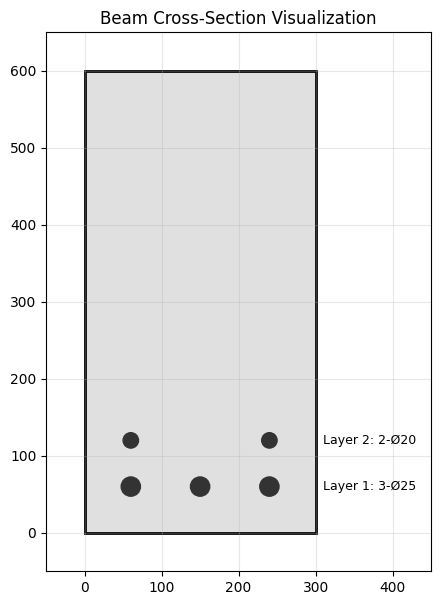

Note: Rebar spacing not to scale, just for visualization purposes.


In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def plot_beam(b, h, layers):
    fig, ax = plt.subplots(figsize=(5, 7))
    
    # Draw Concrete Outline
    ax.add_patch(patches.Rectangle((0, 0), b, h, linewidth=2, edgecolor='black', facecolor='#E0E0E0', label='Concrete'))
    
    for idx, layer in enumerate(layers):
        d_i = layer['d_i']
        y_pos = h - d_i
        bars = layer['bars']
        n = len(bars)
        
        # Center the bars horizontally
        spacing = (b * 0.6 / (n - 1)) if n > 1 else 0
        start_x = b * 0.2 if n > 1 else b * 0.5
        
        for i, dia in enumerate(bars):
            x_pos = start_x + (i * spacing)
            rebar = patches.Circle((x_pos, y_pos), radius=dia/2, color='#333333', zorder=3)
            ax.add_patch(rebar)
        
        plt.text(b + 10, y_pos, f"Layer {idx+1}: {n}-Ø{bars[0]}", va='center', fontsize=9)

    plt.xlim(-50, b + 150)
    plt.ylim(-50, h + 50)
    plt.gca().set_aspect('equal')
    plt.title("Beam Cross-Section Visualization")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_beam(b, h, layers)
print("Note: Rebar spacing not to scale, just for visualization purposes.")

## The Iterative Solver

In [40]:
def calculate_imbalance(c_trial):
    # 1. Concrete Compression (Whitney Stress Block)
    a = beta1 * c_trial
    C_c = 0.85 * fc_prime * a * b
    
    # 2. Steel Tension (Summing all layers)
    T_total = 0
    for layer in layers:
        # Strain compatibility
        epsilon_si = (epsilon_cu * (layer['d_i'] - c_trial)) / c_trial
        
        # Stress: linear-elastic or yielded
        # We use math.copysign to handle potential compression steel (if d_i < c)
        fs_i = max(-fy, min(fy, epsilon_si * Es)) 
        T_total += layer['area'] * fs_i
        
    return C_c - T_total

# --- Bisection Algorithm ---
c_low = h/1000           # Lower bound (cannot be 0)
c_high = h            # Upper bound (entire depth)
tolerance = 0.001      # Newton/Force tolerance
max_iterations = 1000

for i in range(max_iterations):
    c_mid = (c_low + c_high) / 2
    imbalance = calculate_imbalance(c_mid)
    
    if abs(imbalance) < tolerance:
        c_final = c_mid
        print(f"Converged in {i} iterations.")
        break
    
    # Adjust bounds
    # If C > T, the neutral axis needs to move UP (c gets smaller) to reduce C
    if imbalance > 0:
        c_high = c_mid
    else:
        c_low = c_mid
else:
    c_final = (c_low + c_high) / 2
    print("Warning: Max iterations reached without perfect convergence.")

print(f"Converged Neutral Axis (c): {c_final:.2f} mm")

Converged in 25 iterations.
Converged Neutral Axis (c): 145.39 mm


## Final Capacity and Results

In [30]:
# Re-calculate final forces with the converged 'c'
a_final = beta1 * c_final
Mn = 0
d_t = max(layer['d_i'] for layer in layers) # For phi calculation considering the bottom most layer (d_t=d_bottom)

for layer in layers:
    epsilon_si = (epsilon_cu * (layer['d_i'] - c_final)) / c_final
    fs_i = max(-fy, min(fy, epsilon_si * Es))
    
    # Moment arm is from the compression centroid (a/2) to the layer depth
    Mn += layer['area'] * fs_i * (layer['d_i'] - a_final/2)

# Calculate Phi based on extreme tension strain
epsilon_t = (epsilon_cu * (d_t - c_final)) / c_final
if epsilon_t >= 0.005:
    phi = 0.90
elif epsilon_t <= 0.002:
    phi = 0.65
else:
    phi = 0.65 + (epsilon_t - 0.002) * (250/3)

print(f"Extreme steel strain (epsilon_t): {epsilon_t:.5f}")
print(f"Yield strain (epsilon_y): {fy/Es:.5f}")
print(f"Nominal Moment (Mn): {Mn / 1e6:.2f} kN-m")
print(f"Phi (Strength Reduction Factor): {phi:.2f}")
print(f"Design Moment (phiMn): {phi * Mn / 1e6:.2f} kN-m")

Extreme steel strain (epsilon_t): 0.00814
Yield strain (epsilon_y): 0.00210
Nominal Moment (Mn): 406.13 kN-m
Phi (Strength Reduction Factor): 0.90
Design Moment (phiMn): 365.52 kN-m
